# Week 6 Assignment - Image Denoising with an Autoencoder (MNIST)

Name: Deeptesh Mohapatra

Dataset: MNIST - 70,000 grayscale images of handwritten digits, each 28x28 pixels.

Goal: build a deep learning model that can take a noisy image and clean it up. The tool for
this is a denoising autoencoder. I add random noise to the MNIST digits, then train the
autoencoder to turn the noisy image back into the clean one.

Plan:

1. Load MNIST and look at the digits
2. Scale the pixels and add random noise to make noisy versions
3. Build a simple dense autoencoder as a baseline
4. Build a convolutional denoising autoencoder (the main model)
5. Compare the two with pictures and with numbers (MSE and PSNR)
6. Check how well the convolutional model holds up as the noise gets stronger
7. Write up what I found

Idea of an autoencoder: it squeezes the image down to a small summary (the encoder) and then
rebuilds it (the decoder). If I train it with a noisy image as the input and the clean image as
the target, it learns to keep the important shape of the digit and drop the noise.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (11, 4)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Loading MNIST

Keras can download MNIST directly. I only need the images (not the digit labels), because the
autoencoder learns to reproduce the image itself.

Train images: (60000, 28, 28)
Test images : (10000, 28, 28)
Pixel range : 0 to 255


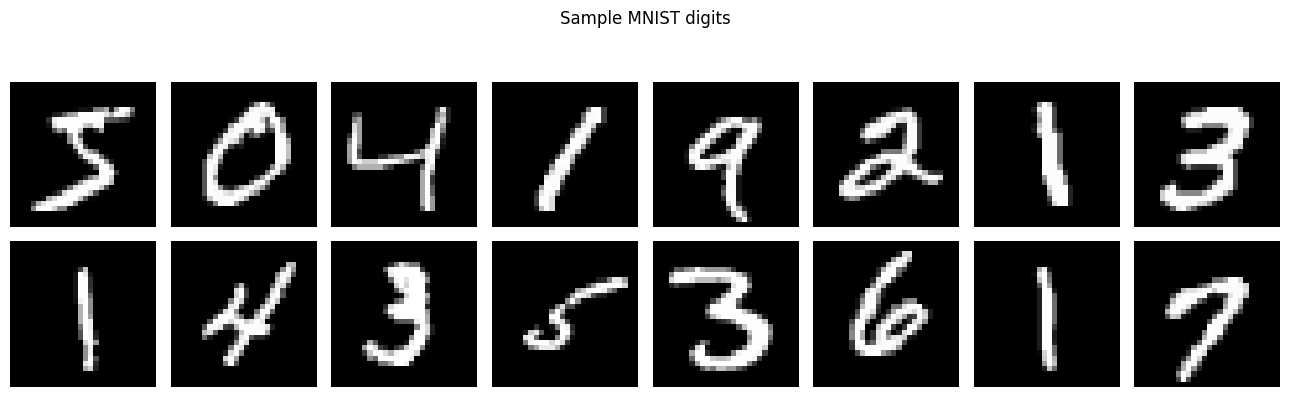

In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
print('Train images:', x_train.shape)
print('Test images :', x_test.shape)
print('Pixel range :', x_train.min(), 'to', x_train.max())

fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Sample MNIST digits', y=1.02)
plt.tight_layout(); plt.show()

## 2. Preprocessing and adding noise

Two steps:

- Scale the pixels from 0-255 down to 0-1 and add a channel dimension so the images are shaped
  (28, 28, 1).
- Make noisy copies by adding random Gaussian noise, then clip back to 0-1. The clean images are
  the targets and the noisy images are the inputs.

The noise factor controls how strong the noise is (0 means none, higher means noisier).

In [3]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

NOISE_FACTOR = 0.5
x_train_noisy = x_train + NOISE_FACTOR * np.random.normal(size=x_train.shape)
x_test_noisy  = x_test  + NOISE_FACTOR * np.random.normal(size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0).astype('float32')
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0).astype('float32')

print('Clean train shape:', x_train.shape)
print('Noisy train shape:', x_train_noisy.shape)

Clean train shape: (60000, 28, 28, 1)
Noisy train shape: (60000, 28, 28, 1)


### 2.1 Clean vs noisy

Top row is the original digit, bottom row is the same digit with noise added. The noisy ones are the input the model has to clean up.

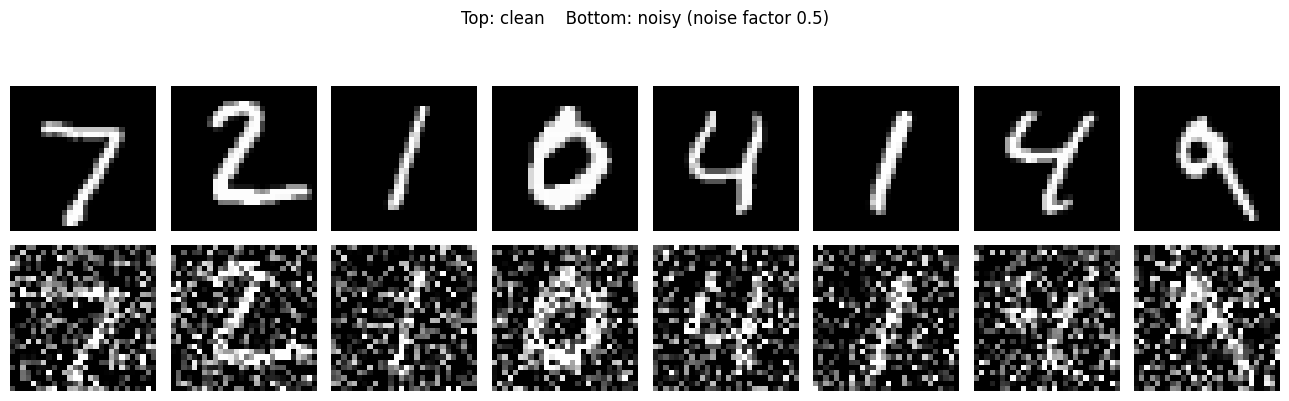

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('clean'); axes[1, 0].set_ylabel('noisy')
plt.suptitle('Top: clean    Bottom: noisy (noise factor ' + str(NOISE_FACTOR) + ')', y=1.03)
plt.tight_layout(); plt.show()

### 2.2 How I will measure quality

I use two numbers to compare a cleaned image with the true clean image:

- MSE (mean squared error): lower is better.
- PSNR (peak signal to noise ratio, in decibels): higher is better. It is the standard measure
  for image reconstruction quality.

In [5]:
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def psnr(a, b):
    m = np.mean((a - b) ** 2)
    if m == 0:
        return 99.0
    return float(20 * np.log10(1.0) - 10 * np.log10(m))   # max pixel value is 1.0

# quality of the noisy images before any denoising (our baseline to beat)
print('Noisy vs clean  MSE :', round(mse(x_test_noisy, x_test), 4))
print('Noisy vs clean  PSNR:', round(psnr(x_test_noisy, x_test), 2), 'dB')

Noisy vs clean  MSE : 0.1155
Noisy vs clean  PSNR: 9.37 dB


## 3. Baseline - a simple dense autoencoder

First a plain fully connected autoencoder. It flattens the image to 784 numbers, squeezes it
down to a small code of 32 numbers, and rebuilds it. Because it throws away the 2D layout, I
expect it to denoise only roughly - it is my baseline.

In [6]:
dense_ae = keras.Sequential([
    layers.Input((28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(32,  activation='relu'),     # the bottleneck / code
    layers.Dense(128, activation='relu'),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1)),
], name='Dense_Autoencoder')
dense_ae.compile(optimizer='adam', loss='binary_crossentropy')
dense_ae.summary()

Model: "Dense_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
hist_dense = dense_ae.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=15, batch_size=256, verbose=2)

Epoch 1/15


235/235 - 6s - 26ms/step - loss: 0.2504 - val_loss: 0.1848


Epoch 2/15


235/235 - 3s - 14ms/step - loss: 0.1712 - val_loss: 0.1596


Epoch 3/15


...

235/235 - 3s - 14ms/step - loss: 0.1280 - val_loss: 0.1273


Epoch 14/15


235/235 - 3s - 15ms/step - loss: 0.1273 - val_loss: 0.1268


Epoch 15/15


235/235 - 3s - 14ms/step - loss: 0.1267 - val_loss: 0.1264


## 4. Convolutional denoising autoencoder (main model)

A convolutional autoencoder keeps the 2D structure of the image. The encoder uses convolution
and pooling to shrink the image down, and the decoder uses convolution and upsampling to build
it back to 28x28. This is the natural design for images, so it should denoise much better than
the dense baseline.

In [8]:
inp = layers.Input((28, 28, 1))
# encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
x = layers.MaxPooling2D(padding='same')(x)          # 14x14
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(padding='same')(x)          # 7x7
# decoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D()(x)                         # 14x14
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D()(x)                         # 28x28
out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

conv_ae = keras.Model(inp, out, name='Conv_Denoising_Autoencoder')
conv_ae.compile(optimizer='adam', loss='binary_crossentropy')
conv_ae.summary()

Model: "Conv_Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
hist_conv = conv_ae.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=10, batch_size=256, verbose=2)

Epoch 1/10


235/235 - 98s - 419ms/step - loss: 0.1967 - val_loss: 0.1247


Epoch 2/10


235/235 - 90s - 382ms/step - loss: 0.1204 - val_loss: 0.1148


Epoch 3/10


...

235/235 - 79s - 337ms/step - loss: 0.1036 - val_loss: 0.1020


Epoch 9/10


235/235 - 80s - 339ms/step - loss: 0.1027 - val_loss: 0.1012


Epoch 10/10


235/235 - 82s - 349ms/step - loss: 0.1018 - val_loss: 0.1005


### 4.1 Training loss for both models

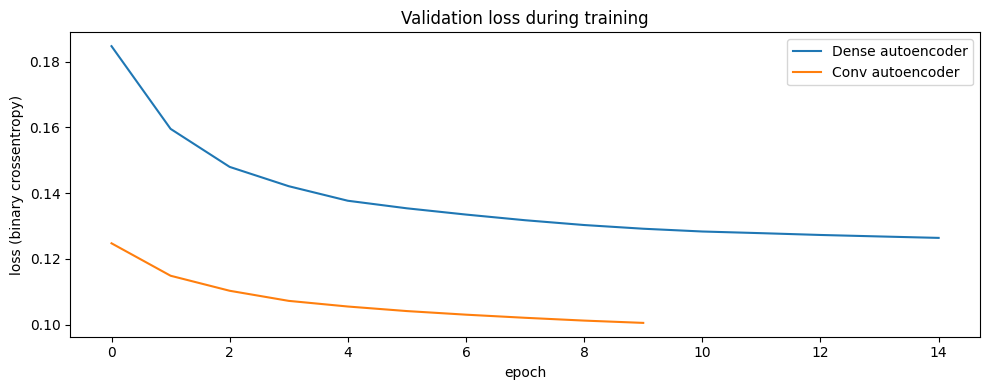

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_dense.history['val_loss'], label='Dense autoencoder')
ax.plot(hist_conv.history['val_loss'], label='Conv autoencoder')
ax.set_title('Validation loss during training')
ax.set_xlabel('epoch'); ax.set_ylabel('loss (binary crossentropy)'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Results - denoised images

Here is the interesting part. For a few test digits I show four rows: the clean original, the
noisy input, the dense model's output, and the convolutional model's output.

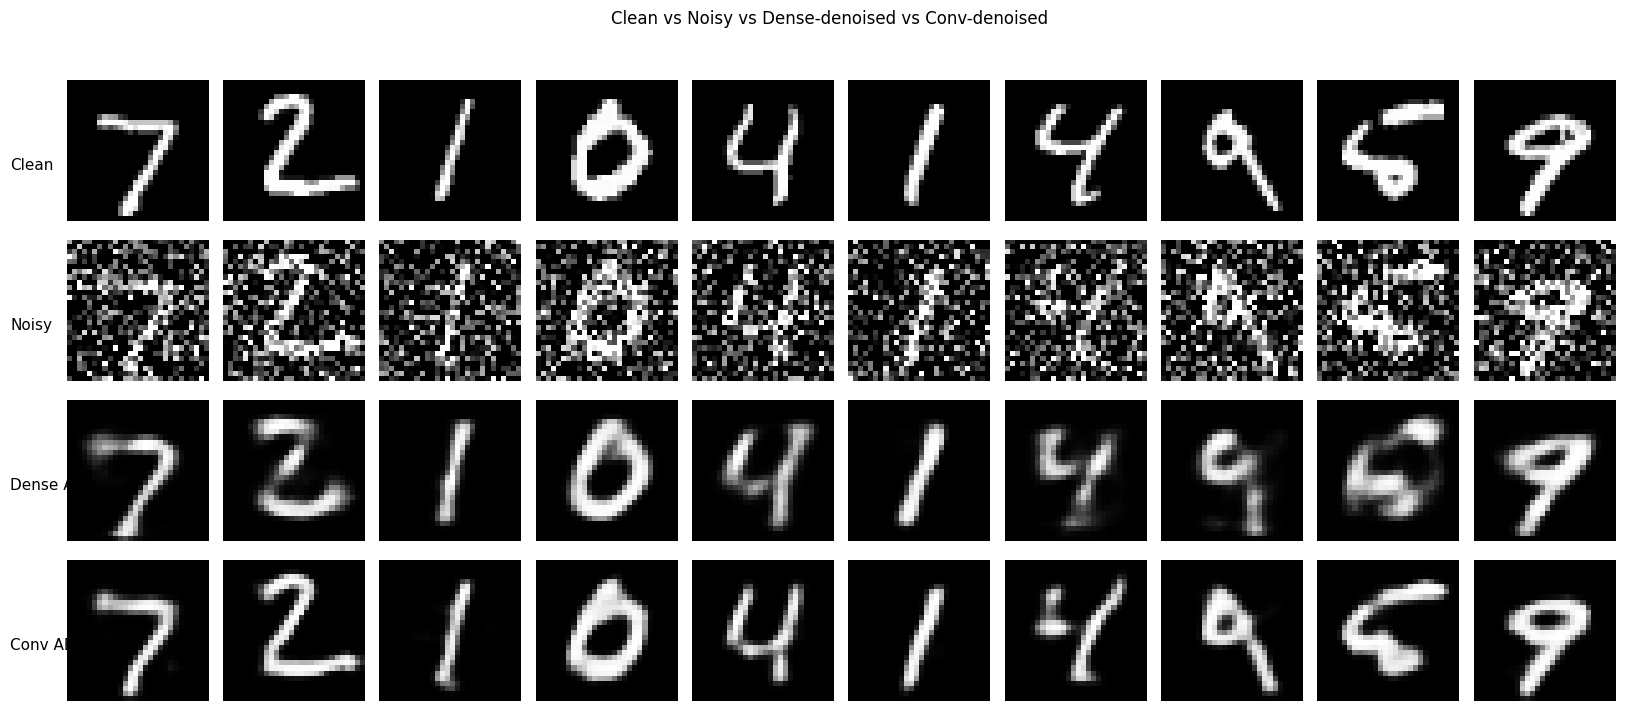

In [11]:
dense_out = dense_ae.predict(x_test_noisy, verbose=0)
conv_out  = conv_ae.predict(x_test_noisy, verbose=0)

n = 10
fig, axes = plt.subplots(4, n, figsize=(16, 7))
rows = [(x_test, 'Clean'), (x_test_noisy, 'Noisy'),
        (dense_out, 'Dense AE'), (conv_out, 'Conv AE')]
for r, (imgs, label) in enumerate(rows):
    for c in range(n):
        axes[r, c].imshow(imgs[c].squeeze(), cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_title(label, loc='left', x=-0.4, y=0.3, fontsize=11)
plt.suptitle('Clean vs Noisy vs Dense-denoised vs Conv-denoised', y=1.02)
plt.tight_layout(); plt.show()

### 5.1 Numbers - MSE and PSNR on the test set

In [12]:
import pandas as pd
table = pd.DataFrame({
    'Version': ['Noisy (no denoising)', 'Dense autoencoder', 'Conv autoencoder'],
    'MSE':  [mse(x_test_noisy, x_test), mse(dense_out, x_test), mse(conv_out, x_test)],
    'PSNR (dB)': [psnr(x_test_noisy, x_test), psnr(dense_out, x_test), psnr(conv_out, x_test)],
}).round(4)
table

,Version,MSE,PSNR (dB)
0,Noisy (no denoising),0.1155,9.3748
1,Dense autoencoder,0.0210,16.7736
2,Conv autoencoder,0.0125,19.0364


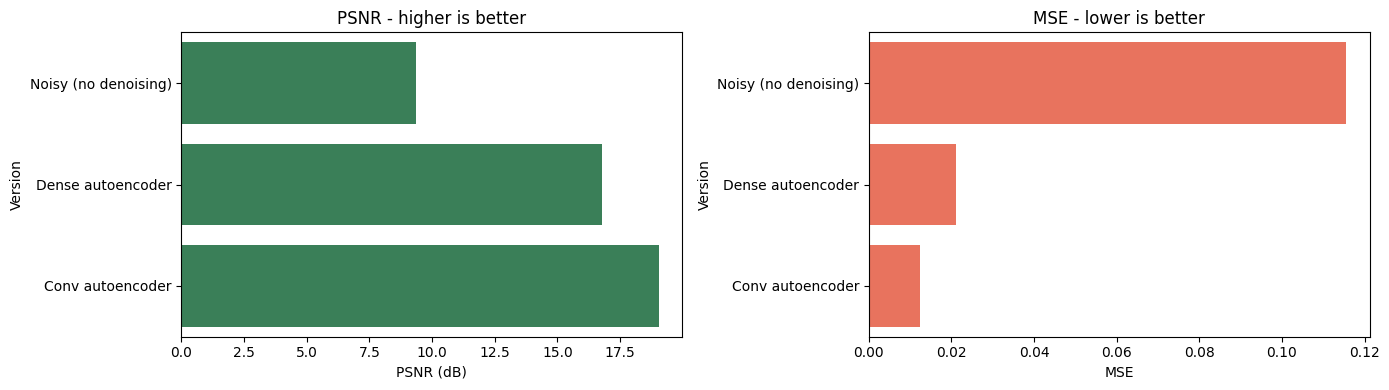

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
import seaborn as sns
sns.barplot(data=table, x='PSNR (dB)', y='Version', ax=axes[0], color='seagreen')
axes[0].set_title('PSNR - higher is better')
sns.barplot(data=table, x='MSE', y='Version', ax=axes[1], color='tomato')
axes[1].set_title('MSE - lower is better')
plt.tight_layout(); plt.show()

## 6. How well does it hold up as the noise gets worse?

The model was trained at noise factor 0.5. Here I take the trained convolutional model and test
it on the test set at several noise levels, from light to heavy, and see how the PSNR of the
cleaned image compares with the PSNR of the noisy image.

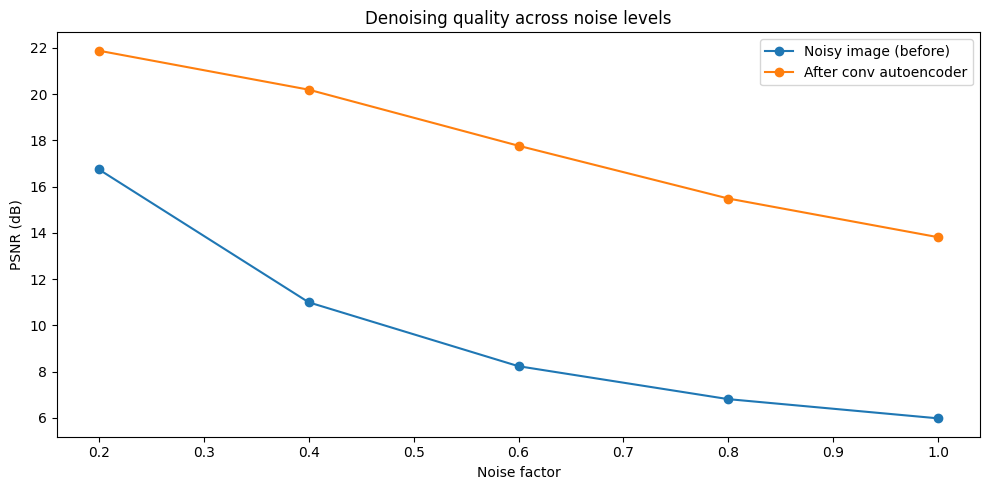

,Noise factor,Noisy PSNR,Denoised PSNR
0,0.2,16.74,21.88
1,0.4,10.99,20.19
2,0.6,8.23,17.77
3,0.8,6.81,15.48
4,1.0,5.98,13.81


In [14]:
levels = [0.2, 0.4, 0.6, 0.8, 1.0]
noisy_psnr, denoised_psnr = [], []
for nf in levels:
    nt = np.clip(x_test + nf * np.random.normal(size=x_test.shape), 0, 1).astype('float32')
    out = conv_ae.predict(nt, verbose=0)
    noisy_psnr.append(psnr(nt, x_test))
    denoised_psnr.append(psnr(out, x_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(levels, noisy_psnr, marker='o', label='Noisy image (before)')
ax.plot(levels, denoised_psnr, marker='o', label='After conv autoencoder')
ax.set_xlabel('Noise factor'); ax.set_ylabel('PSNR (dB)')
ax.set_title('Denoising quality across noise levels')
ax.legend()
plt.tight_layout(); plt.show()

pd.DataFrame({'Noise factor': levels,
              'Noisy PSNR': np.round(noisy_psnr, 2),
              'Denoised PSNR': np.round(denoised_psnr, 2)})

## Conclusion

What I did and what I found:

1. Loaded MNIST and scaled the pixels to 0-1, then made noisy copies by adding Gaussian noise
   (noise factor 0.5) and clipping back to 0-1.
2. Trained two autoencoders to map the noisy image back to the clean one: a simple dense
   autoencoder as a baseline and a convolutional denoising autoencoder.
3. Both models remove a lot of the noise, but the convolutional model is clearly better. Its
   digits come out sharper and cleaner, and it scores a higher PSNR and a lower MSE than both the
   noisy baseline and the dense model.
4. The noise-level test shows the model still helps as the noise gets stronger: even at high noise
   factors the cleaned image has a noticeably higher PSNR than the noisy input, though the gap
   naturally shrinks when the noise starts to hide the digit.

### Model selection conclusion

The convolutional autoencoder is the better choice for image denoising. Because it works on 2D
patches instead of a flattened vector, it keeps the shape of the strokes and can tell a digit
edge apart from random noise. The dense autoencoder still helps - it beats doing nothing - but it
blurs the result more because it ignores the layout of the pixels. So for this task I would pick
the convolutional autoencoder.

### What worked

- Training on (noisy input, clean target) pairs: this is what teaches the model to denoise rather
  than just copy the image.
- Convolution and pooling for the encoder, convolution and upsampling for the decoder: keeps the
  2D structure and gives sharp reconstructions.
- Measuring with PSNR and MSE, not just looking at the pictures, so the comparison is objective.

### Future enhancements

- Try other noise types (salt and pepper, blur) and train on a mix so the model is more general.
- Add skip connections between the encoder and decoder (a U-Net style) to keep fine detail.
- Use a perceptual or SSIM based loss instead of plain pixel error for sharper looking results.
- Try the same idea on larger, color images to see how it scales.